# Laboratorio 7 — NLP end-to-end y Embeddings

## Datos, preprocesamiento y Skip-Gram with Negative Sampling

In [19]:
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
import math, random, re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from torch import nn
from torch.utils.data import DataLoader, IterableDataset

SEED = 42
TOKEN_LIMIT = 20_000_000
MIN_COUNT = 5
WINDOW_SIZE = 5
SUBSAMPLE_THRESHOLD = 1e-5
PAD, UNK = '<pad>', '<unk>'
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TOKEN_RE = re.compile(r"[a-z]+(?:['-][a-z]+)*|\d+(?:[.,]\d+)*", re.I)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


### 1. Normalización y tokenización

El texto se convierte a minúsculas, se descarta la puntuación aislada y se conservan las contracciones y los guiones internos. Los números se mantienen textuales para no introducir `<num>`, token que no necesariamente existe en GloVe. La misma función se usa con WikiText y con AG News.

In [20]:
def tokenize(text, lowercase=True, replace_numbers=False):
    if lowercase:
        text = text.lower()
    tokens = TOKEN_RE.findall(text)
    return ['<num>' if replace_numbers and token[0].isdigit() else token for token in tokens]

examples = [
    "I can't believe it's already Jan. 5th!",
    "The state-of-the-art model costs $1,299.99.",
    "Dr. Smith lives in the U.S.A.",
    "We're testing e-mail and co-operate.",
    "Don't split O'Connor incorrectly.",
    "The 3.14 value isn't an integer.",
    "NASA's launch was re-scheduled.",
    "Mr. Jones said: 'Hello!'",
    "This is a well-known edge-case.",
    "They'll arrive at 10:30 p.m.",
]
import spacy
nlp = spacy.blank('en')
comparison = pd.DataFrame({
    'oracion': examples,
    'tokenizador_propio': [tokenize(text) for text in examples],
    'spacy': [[token.text for token in nlp(text)] for text in examples],
})
comparison['coinciden'] = comparison.tokenizador_propio == comparison.spacy
comparison

,oracion,tokenizador_propio,spacy,coinciden
0,I can't believe it's already Jan. 5th!,"[i, can't, believe, it's, already, jan, 5, th]","[I, ca, n't, believe, it, 's, already, Jan., 5...",False
1,"The state-of-the-art model costs $1,299.99.","[the, state-of-the-art, model, costs, 1,299.99]","[The, state, -, of, -, the, -, art, model, cos...",False
2,Dr. Smith lives in the U.S.A.,"[dr, smith, lives, in, the, u, s, a]","[Dr., Smith, lives, in, the, U.S.A.]",False
3,We're testing e-mail and co-operate.,"[we're, testing, e-mail, and, co-operate]","[We, 're, testing, e, -, mail, and, co, -, ope...",False
4,Don't split O'Connor incorrectly.,"[don't, split, o'connor, incorrectly]","[Do, n't, split, O'Connor, incorrectly, .]",False
5,The 3.14 value isn't an integer.,"[the, 3.14, value, isn't, an, integer]","[The, 3.14, value, is, n't, an, integer, .]",False
6,NASA's launch was re-scheduled.,"[nasa's, launch, was, re-scheduled]","[NASA, 's, launch, was, re, -, scheduled, .]",False
7,Mr. Jones said: 'Hello!',"[mr, jones, said, hello]","[Mr., Jones, said, :, ', Hello, !, ']",False
8,This is a well-known edge-case.,"[this, is, a, well-known, edge-case]","[This, is, a, well, -, known, edge, -, case, .]",False
9,They'll arrive at 10:30 p.m.,"[they'll, arrive, at, 10, 30, p, m]","[They, 'll, arrive, at, 10:30, p.m.]",False


In [21]:
def build_corpus(split, limit=TOKEN_LIMIT):
    documents, articles, lines, tokens = [], 0, 0, 0
    for row in split:
        articles += 1
        words = tokenize(row['text'])
        if not words:
            continue
        remaining = limit - tokens
        if remaining <= 0:
            break
        words = words[:remaining]
        documents.append(words)  # no cruzar contextos entre líneas
        lines += 1; tokens += len(words)
        if tokens == limit:
            break
    return documents, {'articulos': articles, 'lineas_no_vacias': lines, 'tokens': tokens}

wikitext_train = load_dataset('Salesforce/wikitext', 'wikitext-103-raw-v1', split='train')
documents, corpus_stats = build_corpus(wikitext_train)
corpus_stats

{'articulos': 416152, 'lineas_no_vacias': 269360, 'tokens': 20000000}

Cobertura: {10: 0.24240295, 1000: 0.64760145, 30000: 0.9606905}


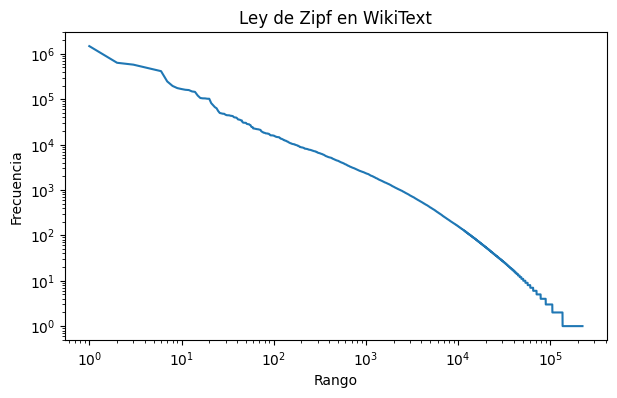

,min_count,tamano_vocabulario,porcentaje_desconocido
0,2,135404,0.438060
1,5,78363,1.194265
2,10,53522,2.009240


In [22]:
# Frecuencias, ley de Zipf y cobertura de palabras frecuentes
counts = Counter(token for document in documents for token in document)
total_tokens = sum(counts.values())
ranked = counts.most_common()
coverage = {k: sum(count for _, count in ranked[:k]) / total_tokens for k in (10, 1_000, 30_000)}
print('Cobertura:', coverage)
plt.figure(figsize=(7, 4))
plt.loglog(range(1, len(ranked) + 1), [count for _, count in ranked])
plt.xlabel('Rango'); plt.ylabel('Frecuencia'); plt.title('Ley de Zipf en WikiText')
plt.show()

def make_vocab(min_count):
    tokens = [token for token, count in ranked if count >= min_count]
    id_to_token = [PAD, UNK, *tokens]
    token_to_id = {token: index for index, token in enumerate(id_to_token)}
    unknown = sum(count for token, count in counts.items() if token not in token_to_id) / total_tokens
    return token_to_id, id_to_token, unknown

vocab_sweep = []
for threshold in (2, 5, 10):
    mapping, terms, unknown_rate = make_vocab(threshold)
    vocab_sweep.append({'min_count': threshold, 'tamano_vocabulario': len(terms), 'porcentaje_desconocido': 100 * unknown_rate})
pd.DataFrame(vocab_sweep)

In [23]:
# Subsampling y pares (central, contexto) para skip-gram
token_to_id, id_to_token, unknown_rate = make_vocab(MIN_COUNT)

def keep_probability(token):
    frequency = counts[token] / total_tokens
    return min(1.0, (math.sqrt(frequency / SUBSAMPLE_THRESHOLD) + 1) * SUBSAMPLE_THRESHOLD / frequency)

rng = random.Random(SEED)
sampled_documents = [[token for token in document if rng.random() < keep_probability(token)] for document in documents]
sampled_documents = [document for document in sampled_documents if document]
discarded = {word: 100 * (1 - keep_probability(word)) for word in ('the', 'of', 'and')}

def encode(documents):
    return [[token_to_id.get(token, token_to_id[UNK]) for token in document] for document in documents]

def pair_count(encoded_documents, window=WINDOW_SIZE):
    return sum(sum(min(i, window) + min(len(document) - i - 1, window) for i in range(len(document))) for document in encoded_documents)

encoded = encode(documents)
sampled_encoded = encode(sampled_documents)
pd.Series({'vocabulario': len(id_to_token), 'oov_corpus_pct': 100 * unknown_rate, 'pares_antes': pair_count(encoded), 'pares_despues': pair_count(sampled_encoded), **{f'descartado_{word}_pct': rate for word, rate in discarded.items()}})

,0
vocabulario,7.836300e+04
oov_corpus_pct,1.194265e+00
pares_antes,1.928557e+08
pares_despues,6.542936e+07
descartado_the_pct,9.882276e+01
descartado_of_pct,9.819334e+01
descartado_and_pct,9.810393e+01


### 2. SGNS propio en PyTorch

Se usan dos tablas: `input_embeddings` es W y `output_embeddings` es W'. Al finalizar se exporta W como representación de palabras.

In [24]:
def skipgram_pairs(encoded_documents, window=WINDOW_SIZE):
    for document in encoded_documents:
        for i, center in enumerate(document):
            for j in range(max(0, i-window), min(len(document), i+window+1)):
                if i != j:
                    yield center, document[j]

class PairDataset(IterableDataset):
    def __init__(self, docs, window): self.docs, self.window = docs, window
    def __iter__(self): yield from skipgram_pairs(self.docs, self.window)

class SGNS(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.input_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.output_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        nn.init.uniform_(self.input_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.output_embeddings.weight)
    def forward(self, centers, positives, negatives):
        center = self.input_embeddings(centers)
        positive = (center * self.output_embeddings(positives)).sum(1)
        negative = torch.bmm(self.output_embeddings(negatives), center.unsqueeze(2)).squeeze(2)
        return -(torch.nn.functional.logsigmoid(positive) + torch.nn.functional.logsigmoid(-negative).sum(1)).mean()

negative_weights = torch.tensor([counts.get(token, 0)**0.75 for token in id_to_token], dtype=torch.float)
negative_weights[:2] = 0
negative_weights /= negative_weights.sum()

def train_sgns(model, docs, epochs=5, negatives=10, batch_size=2048, learning_rate=0.025, metric_callback=None):
    model.to(DEVICE); optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []
    for epoch in range(1, epochs + 1):
        if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
        started = perf_counter(); loss_sum = 0; pairs = 0
        for centers, positives in DataLoader(PairDataset(docs, WINDOW_SIZE), batch_size=batch_size):
            centers, positives = centers.to(DEVICE), positives.to(DEVICE)
            negative_ids = torch.multinomial(negative_weights.to(DEVICE), centers.numel() * negatives, replacement=True).view(-1, negatives)
            optimizer.zero_grad(set_to_none=True)
            loss = model(centers, positives, negative_ids); loss.backward(); optimizer.step()
            loss_sum += loss.item() * len(centers); pairs += len(centers)
        metrics = metric_callback(model, epoch) if metric_callback else {}
        peak = torch.cuda.max_memory_allocated(DEVICE) / 2**20 if DEVICE.type == 'cuda' else np.nan
        history.append({'epoch': epoch, 'loss': loss_sum/pairs, 'pares': pairs, 'segundos': perf_counter()-started, 'gpu_mib': peak, **metrics})
    return pd.DataFrame(history)

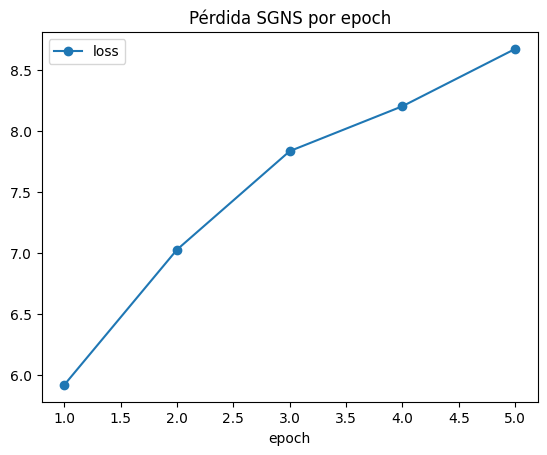

Vectores guardados en ../artifacts/sgns_best_vectors.txt


In [25]:
# Corrida base: 100 dimensiones sobre el subconjunto completo.
SONDA_ANALOGIAS = [
    ('paris', 'france', 'rome', 'italy'),
    ('man', 'woman', 'king', 'queen'),
    ('good', 'better', 'bad', 'worse'),
    ('big', 'bigger', 'small', 'smaller'),
    ('car', 'cars', 'house', 'houses'),
    ('france', 'euro', 'japan', 'yen'),
]

def sonda_analogias(modelo, epoch):
    with torch.no_grad():
        peso = modelo.input_embeddings.weight.detach()
        unitarios = peso / peso.norm(dim=1, keepdim=True).clamp_min(1e-12)
        cubiertas = aciertos = 0
        for a, b, c, d in SONDA_ANALOGIAS:
            if any(palabra not in token_to_id for palabra in (a, b, c, d)):
                continue
            ia, ib, ic, idestino = (token_to_id[palabra] for palabra in (a, b, c, d))
            consulta = unitarios[ib] - unitarios[ia] + unitarios[ic]
            consulta = consulta / consulta.norm().clamp_min(1e-12)
            puntajes = unitarios @ consulta
            puntajes[ia] = -1e30
            puntajes[ib] = -1e30
            puntajes[ic] = -1e30
            cubiertas += 1
            aciertos += int(puntajes.argmax().item() == idestino)
    return {'analogias_add': aciertos / cubiertas if cubiertas else float('nan')}

model = SGNS(len(id_to_token), embedding_dim=100)
history = train_sgns(
    model, sampled_encoded, epochs=5, negatives=10, batch_size=2048,
    learning_rate=0.025, metric_callback=sonda_analogias,
)
history.plot(x='epoch', y='loss', marker='o', title='Pérdida SGNS por epoch')
plt.show()

# Exportar W en formato word2vec.
output = Path('../artifacts/sgns_best_vectors.txt')
output.parent.mkdir(exist_ok=True)
vectors = model.input_embeddings.weight.detach().cpu().numpy()
with output.open('w', encoding='utf-8') as file:
    file.write(f'{len(id_to_token)-2} {vectors.shape[1]}\n')
    for token, vector in zip(id_to_token[2:], vectors[2:]):
        file.write(f"{token} {' '.join(map(str, vector))}\n")
print(f'Vectores guardados en {output}')

### 6. Embeddings de referencia

Gensim entrena skip-gram con muestreo negativo sobre el mismo corpus tokenizado y el mismo vocabulario que SGNS. La dimensión, la ventana, el mínimo de frecuencia, el umbral de submuestreo, el número de negativos, el exponente 0.75 de la distribución unigramal y las épocas salen de la corrida SGNS de 100 dimensiones sobre el 100 % del subconjunto. Gensim optimiza con SGD y el calendario de Word2Vec; SGNS propio optimiza con Adam. La ventana queda fija, igual que en el generador de pares propio.

GloVe se usa en 100 dimensiones, preentrenado en Wikipedia 2014 y Gigaword 5, sin ajuste sobre WikiText. Conserva su vocabulario original. La representación de SGNS es la tabla de entrada.

`nn.EmbeddingBag` reduce una bolsa de índices a un vector. Con `mode='mean'` ese vector es el promedio de las palabras del documento. `offsets` marca dónde empieza cada noticia dentro del tensor plano de tokens, así que un lote puede mezclar textos de distinta longitud sin relleno. El índice de relleno no entra en el promedio.

CBOW predice la palabra central a partir del contexto. Skip-gram predice el contexto a partir de la palabra central: hace más actualizaciones por palabra y suele representar mejor los términos poco frecuentes. El modelo propio y el de gensim son skip-gram.

Word2Vec aprende de pares locales dentro de la ventana. GloVe reconstruye el logaritmo de coocurrencias contadas en todo el corpus. GloVe llega con las estadísticas de otro corpus y con un vocabulario distinto; su tasa de palabras fuera de vocabulario en AG News se calcula sobre ese vocabulario original.


In [26]:
import platform
import urllib.request

from IPython.display import display

import gensim.downloader as api
from gensim.models import Word2Vec

DATA_DIR = Path('../data')
ARTIFACTS = Path('../artifacts')
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)
DIMENSION = int(model.input_embeddings.embedding_dim)
EPOCHS_W2V = int(history['epoch'].max()) if len(history) else 5
NEGATIVOS = 10
REPO_URL = 'https://github.com/diegoanro22/DL-LAB07'
HARDWARE = f'{platform.platform()}; dispositivo {DEVICE}; torch {torch.__version__}'

def descargar(url, destino):
    destino = Path(destino)
    if destino.exists() and destino.stat().st_size > 0:
        return destino
    urllib.request.urlretrieve(url, destino)
    return destino

class Espacio:
    def __init__(self, nombre, palabras, matriz):
        self.nombre = nombre
        self.palabras = list(palabras)
        self.indice = {palabra: i for i, palabra in enumerate(self.palabras)}
        self.crudos = np.asarray(matriz, dtype=np.float32)
        normas = np.linalg.norm(self.crudos, axis=1, keepdims=True)
        normas[normas == 0] = 1.0
        self.unitarios = self.crudos / normas

    def __contains__(self, palabra):
        return palabra in self.indice

    def __len__(self):
        return len(self.palabras)

    def restringir(self, palabras):
        indices = [self.indice[palabra] for palabra in palabras]
        return Espacio(self.nombre, palabras, self.crudos[indices])

matriz_sgns = model.input_embeddings.weight.detach().cpu().numpy().copy()
espacio_sgns = Espacio('sgns', id_to_token[2:], matriz_sgns[2:])
pesos_sgns = matriz_sgns.astype(np.float32, copy=True)

frecuencias = {token: int(counts[token]) for token in id_to_token[2:]}
w2v = Word2Vec(
    vector_size=DIMENSION,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    sg=1,
    hs=0,
    negative=NEGATIVOS,
    ns_exponent=0.75,
    sample=SUBSAMPLE_THRESHOLD,
    shrink_windows=False,
    epochs=EPOCHS_W2V,
    seed=SEED,
    workers=1,
    alpha=0.025,
    min_alpha=1e-4,
)
inicio = perf_counter()
w2v.build_vocab_from_freq(frecuencias, corpus_count=len(documents))
w2v.train(documents, total_examples=len(documents), epochs=w2v.epochs)
segundos_gensim = perf_counter() - inicio
espacio_gensim = Espacio('gensim', w2v.wv.index_to_key, w2v.wv.vectors)

inicio = perf_counter()
glove = api.load('glove-wiki-gigaword-100')
segundos_glove = perf_counter() - inicio
espacio_glove = Espacio('glove', glove.index_to_key, glove.vectors)
espacios = {'sgns': espacio_sgns, 'gensim': espacio_gensim, 'glove': espacio_glove}

def alinear_glove(keyed, tokens):
    matriz = np.zeros((len(tokens), keyed.vector_size), dtype=np.float32)
    conocidos = []
    for indice, token in enumerate(tokens):
        if indice < 2 or token not in keyed:
            continue
        matriz[indice] = keyed[token]
        conocidos.append(matriz[indice])
    if conocidos:
        matriz[1] = np.mean(conocidos, axis=0)
    return matriz

pesos_glove = alinear_glove(glove, id_to_token)

ag_news = load_dataset('fancyzhx/ag_news')
textos_ag = list(ag_news['train']['text'])
etiquetas_ag = list(ag_news['train']['label'])
textos_ag_test = list(ag_news['test']['text'])
etiquetas_ag_test = list(ag_news['test']['label'])

def tasa_oov(textos, vocabulario):
    vocabulario = set(vocabulario)
    total = fuera = 0
    for texto in textos:
        for token in tokenize(texto):
            total += 1
            fuera += token not in vocabulario
    return fuera / total if total else float('nan')

muestras = textos_ag[:8]
revision_tokens = pd.DataFrame({
    'texto': muestras,
    'tokens': [tokenize(texto) for texto in muestras],
})
casos = [
    "I can't believe it's already Jan. 5th!",
    "The state-of-the-art model costs $1,299.99.",
    "We're testing e-mail and co-operate.",
    "Don't split O'Connor incorrectly.",
]
filas_casos = []
for frase in casos:
    for token in tokenize(frase):
        filas_casos.append({
            'frase': frase,
            'token': token,
            'en_sgns': token in espacio_sgns,
            'en_gensim': token in espacio_gensim,
            'en_glove': token in espacio_glove,
        })
cobertura_muestra = {
    'sgns': tasa_oov(textos_ag[:2000], espacio_sgns.palabras),
    'gensim': tasa_oov(textos_ag[:2000], espacio_gensim.palabras),
    'glove': tasa_oov(textos_ag[:2000], espacio_glove.palabras),
}
print('OOV en 2000 noticias de AG News:', {k: round(v, 4) for k, v in cobertura_muestra.items()})
print(f'gensim: vocabulario {len(espacio_gensim)}, {segundos_gensim:.1f} s')
print(f'GloVe: vocabulario {len(espacio_glove)}, dimensión {glove.vector_size}, carga {segundos_glove:.1f} s')
display(revision_tokens)
pd.DataFrame(filas_casos)


OOV en 2000 noticias de AG News: {'sgns': 0.0559, 'gensim': 0.0559, 'glove': 0.0217}
gensim: vocabulario 78361, 806.3 s
GloVe: vocabulario 400000, dimensión 100, carga 52.4 s


,texto,tokens
0,Wall St. Bears Claw Back Into the Black (Reute...,"[wall, st, bears, claw, back, into, the, black..."
1,Carlyle Looks Toward Commercial Aerospace (Reu...,"[carlyle, looks, toward, commercial, aerospace..."
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,"[oil, and, economy, cloud, stocks, outlook, re..."
3,Iraq Halts Oil Exports from Main Southern Pipe...,"[iraq, halts, oil, exports, from, main, southe..."
4,"Oil prices soar to all-time record, posing new...","[oil, prices, soar, to, all-time, record, posi..."
5,"Stocks End Up, But Near Year Lows (Reuters) Re...","[stocks, end, up, but, near, year, lows, reute..."
6,Money Funds Fell in Latest Week (AP) AP - Asse...,"[money, funds, fell, in, latest, week, ap, ap,..."
7,Fed minutes show dissent over inflation (USATO...,"[fed, minutes, show, dissent, over, inflation,..."


,frase,token,en_sgns,en_gensim,en_glove
0,I can't believe it's already Jan. 5th!,i,True,True,True
1,I can't believe it's already Jan. 5th!,can't,False,False,False
2,I can't believe it's already Jan. 5th!,believe,True,True,True
3,I can't believe it's already Jan. 5th!,it's,False,False,False
4,I can't believe it's already Jan. 5th!,already,True,True,True
5,I can't believe it's already Jan. 5th!,jan,True,True,True
6,I can't believe it's already Jan. 5th!,5,True,True,True
7,I can't believe it's already Jan. 5th!,th,True,True,True
8,"The state-of-the-art model costs $1,299.99.",the,True,True,True
9,"The state-of-the-art model costs $1,299.99.",state-of-the-art,False,False,True


### 7. Similitud y analogías

`analogia(a, b, c, k)` resuelve la consulta con 3CosAdd: normaliza los vectores, busca el más cercano a \(b - a + c\) y excluye \(a\), \(b\) y \(c\). 3CosMul multiplica los cosenos de \(b\) y \(c\) y divide por el coseno de \(a\), con el coseno desplazado al intervalo (0, 1). Esa función, sobre el vocabulario completo de gensim, se compara con `most_similar`.

Hay 15 analogías de cinco categorías: capitales, género, plural, comparativos y moneda. De cada modelo se guardan el top-5, sus similitudes, el rango de la respuesta esperada y la primera respuesta cuando no se excluye la consulta.

La evaluación por categorías usa las 30 000 palabras más frecuentes de WikiText que están en los tres vocabularios. Se reportan cobertura y accuracy con 3CosAdd y 3CosMul. El t-SNE proyecta unas 500 palabras temáticas de ese vocabulario compartido. La similitud de paralelismo es el coseno medio entre los vectores diferencia \(b - a\) y \(d - c\).


Vocabulario compartido: 30000 palabras
Coincidencia con most_similar: True
Categorías de questions-words: 14


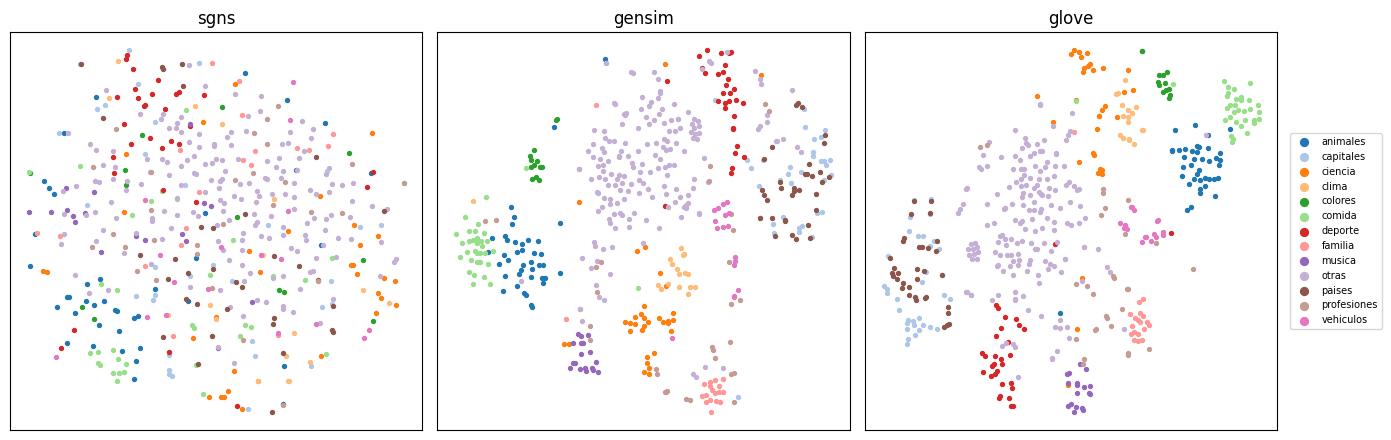

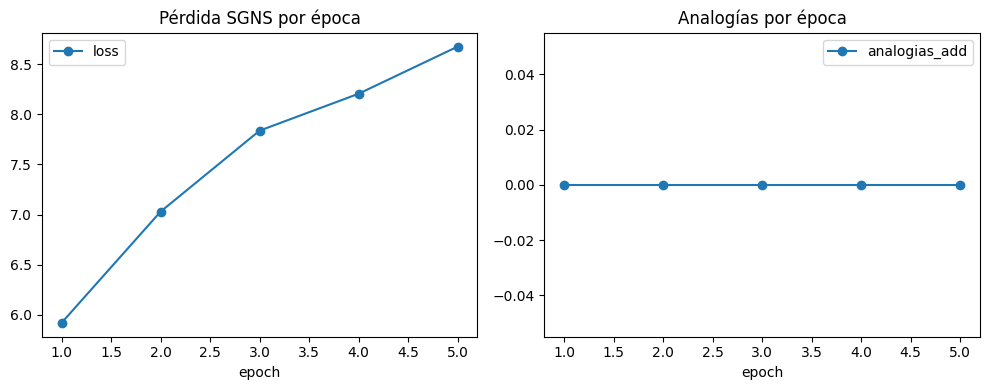

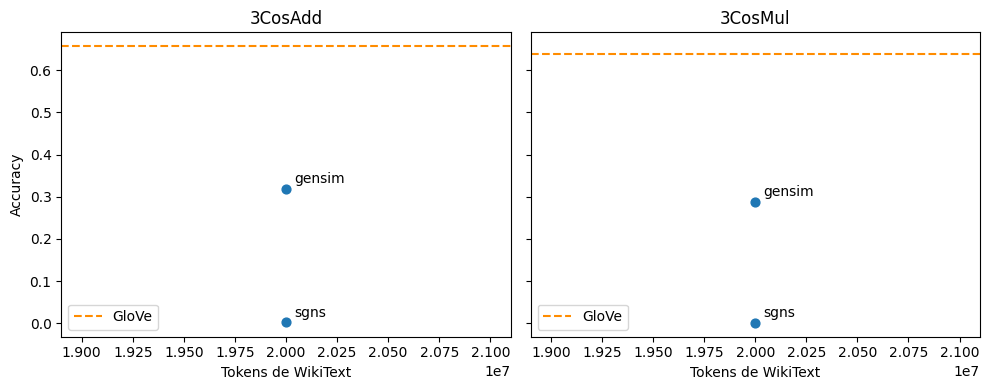

,categoria,consulta,analogia,most_similar,coincide
0,capitales,paris:france :: rome:?,"[carthage, gaul, carthaginian, legions, samnite]","[carthage, gaul, carthaginian, legions, samnite]",True
1,capitales,madrid:spain :: berlin:?,"[germany, sardinia, vienna, prussia, europe]","[germany, sardinia, vienna, prussia, europe]",True
2,capitales,tokyo:japan :: cairo:?,"[libya, basra, lydda, transjordan, haganah]","[libya, basra, lydda, transjordan, haganah]",True
3,genero,man:woman :: king:?,"[marriage, electress, childless, 1553, margrete]","[marriage, electress, childless, 1553, margrete]",True
4,genero,boy:girl :: father:?,"[husband, daughter, wife, siblings, nieces]","[husband, daughter, wife, siblings, nieces]",True


,modelo,categoria,a,b,c,esperada,top5,similitudes,rango,sin_exclusion
0,sgns,capitales,paris,france,rome,italy,"wranglers, bennett, matrimony, red, this","0.455, 0.418, 0.401, 0.399, 0.399",53226,rome
1,gensim,capitales,paris,france,rome,italy,"carthage, gaul, carthaginian, legions, samnite","0.717, 0.714, 0.713, 0.709, 0.688",212,rome
2,glove,capitales,paris,france,rome,italy,"italy, spain, germany, portugal, roman","0.830, 0.710, 0.667, 0.655, 0.653",1,italy
3,sgns,capitales,madrid,spain,berlin,germany,"distrusted, hellish, plantation, knowledge, un...","0.411, 0.400, 0.394, 0.390, 0.387",56200,spain
4,gensim,capitales,madrid,spain,berlin,germany,"germany, sardinia, vienna, prussia, europe","0.729, 0.623, 0.614, 0.608, 0.601",1,berlin
5,glove,capitales,madrid,spain,berlin,germany,"germany, austria, poland, denmark, switzerland","0.819, 0.784, 0.701, 0.695, 0.673",1,germany
6,sgns,capitales,tokyo,japan,cairo,egypt,"millennium, round, doordarshan, theatres, admi...","0.404, 0.389, 0.387, 0.381, 0.380",35831,japan
7,gensim,capitales,tokyo,japan,cairo,egypt,"libya, basra, lydda, transjordan, haganah","0.677, 0.672, 0.666, 0.665, 0.665",16,cairo
8,glove,capitales,tokyo,japan,cairo,egypt,"egypt, morocco, syria, egyptian, arabia","0.819, 0.690, 0.683, 0.673, 0.667",1,egypt
9,sgns,genero,man,woman,king,queen,"expectation, koenig, attest, apamea, libanius","0.441, 0.431, 0.427, 0.404, 0.399",10071,woman


modelo                       gensim           glove            sgns        
metodo                      3cosadd 3cosmul 3cosadd 3cosmul 3cosadd 3cosmul
categoria                                                                  
capital-common-countries      0.455   0.440   0.933   0.917   0.000   0.000
capital-world                 0.336   0.312   0.891   0.865   0.005   0.002
city-in-state                 0.197   0.183   0.318   0.284   0.000   0.001
currency                      0.014   0.029   0.057   0.057   0.000   0.000
family                        0.348   0.322   0.883   0.874   0.000   0.000
gram1-adjective-to-adverb     0.090   0.067   0.278   0.280   0.000   0.000
gram2-opposite                0.037   0.029   0.272   0.235   0.000   0.000
gram3-comparative             0.251   0.233   0.803   0.778   0.000   0.000
gram4-superlative             0.130   0.128   0.613   0.617   0.001   0.001
gram5-present-participle      0.268   0.218   0.722   0.714   0.000   0.000
gram6-nationality-adjective   0.743   0.696   0.974   0.958   0.005   0.003
gram7-past-tense              0.440   0.390   0.575   0.550   0.001   0.001
gram8-plural                  0.364   0.289   0.792   0.753   0.011   0.004
gram9-plural-verbs            0.202   0.185   0.578   0.597   0.000   0.000

,modelo,corpus,vocabulario,dimension,segundos,hardware,analogias_add,analogias_mul,analogias_semanticas,analogias_sintacticas,cobertura_analogias,wordsim,wordsim_cobertura,simlex,simlex_cobertura,wordsim_compartido,simlex_compartido,similitud_diferencias
0,sgns,"WikiText-103, 20M tokens",78361,100,1584.9761,Linux-6.6.122+-x86_64-with-glibc2.39; disposit...,0.0021,0.0011,0.0016,0.0024,0.6237,0.1658,0.9943,0.0393,0.994,0.1732,0.0390,0.0068
1,gensim,"WikiText-103, 20M tokens",78361,100,806.3338,Linux-6.6.122+-x86_64-with-glibc2.39; disposit...,0.3189,0.2884,0.2785,0.3376,0.6237,0.6067,0.9943,0.3014,0.994,0.6173,0.2966,0.1625
2,glove,Wikipedia 2014 + Gigaword 5,400000,100,52.3627,Linux-6.6.122+-x86_64-with-glibc2.39; disposit...,0.6568,0.6380,0.6098,0.6786,0.6237,0.5287,0.9972,0.2975,1.000,0.5546,0.3036,0.4180


In [27]:
import inspect

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.manifold import TSNE

URLS = {
    'questions-words.txt': 'https://raw.githubusercontent.com/nicholas-leonard/word2vec/master/questions-words.txt',
    'wordsim353.csv': 'https://raw.githubusercontent.com/mfaruqui/eval-word-vectors/master/data/word-sim/EN-WS-353-ALL.txt',
    'simlex999.txt': 'https://raw.githubusercontent.com/mfaruqui/eval-word-vectors/master/data/word-sim/EN-SIMLEX-999.txt',
}
rutas_eval = {nombre: descargar(url, DATA_DIR / nombre) for nombre, url in URLS.items()}

ANALOGIAS_PROPIAS = [
    ('capitales', 'paris', 'france', 'rome', 'italy'),
    ('capitales', 'madrid', 'spain', 'berlin', 'germany'),
    ('capitales', 'tokyo', 'japan', 'cairo', 'egypt'),
    ('genero', 'man', 'woman', 'king', 'queen'),
    ('genero', 'boy', 'girl', 'father', 'mother'),
    ('genero', 'actor', 'actress', 'prince', 'princess'),
    ('plural', 'car', 'cars', 'house', 'houses'),
    ('plural', 'city', 'cities', 'country', 'countries'),
    ('plural', 'mouse', 'mice', 'child', 'children'),
    ('comparativo', 'good', 'better', 'bad', 'worse'),
    ('comparativo', 'big', 'bigger', 'small', 'smaller'),
    ('comparativo', 'fast', 'faster', 'slow', 'slower'),
    ('moneda', 'france', 'euro', 'japan', 'yen'),
    ('moneda', 'america', 'dollar', 'england', 'pound'),
    ('moneda', 'germany', 'euro', 'china', 'yuan'),
]

TEMATICAS = {
    'paises': 'france spain italy germany japan china egypt india brazil mexico canada australia russia england ireland scotland greece portugal sweden norway poland turkey iran iraq israel egypt nigeria kenya argentina chile peru cuba korea vietnam thailand'.split(),
    'capitales': 'paris rome berlin madrid london tokyo cairo moscow beijing delhi ottawa canberra dublin lisbon athens stockholm oslo warsaw ankara tehran baghdad jerusalem lagos nairobi buenos santiago lima havana seoul hanoi bangkok amsterdam brussels vienna prague budapest'.split(),
    'animales': 'dog cat horse cow pig sheep bird fish lion tiger bear wolf fox deer mouse rat snake eagle shark whale dolphin elephant monkey rabbit frog turtle penguin goat chicken duck goose camel leopard zebra giraffe crocodile octopus spider ant bee butterfly'.split(),
    'comida': 'bread rice meat fish cheese milk egg apple bread wine beer coffee tea sugar salt bread soup salad fruit vegetable potato tomato onion garlic chicken beef pork butter oil cake bread honey chocolate banana orange grape lemon pepper salt sugar'.split(),
    'deporte': 'football soccer baseball basketball tennis golf hockey cricket rugby boxing swimming running cycling skiing racing coach player team game match goal ball stadium olympic champion league cup final score victory defeat'.split(),
    'profesiones': 'doctor teacher lawyer engineer scientist writer artist farmer soldier nurse driver pilot judge police chef priest student professor journalist actor musician builder sailor merchant banker soldier king queen president minister'.split(),
    'ciencia': 'atom cell energy force mass light water oxygen carbon hydrogen theory experiment physics chemistry biology mathematics planet star moon earth sun gravity electron molecule gene protein climate metal rock crystal acid theory data model'.split(),
    'familia': 'father mother son daughter brother sister husband wife uncle aunt cousin parent child baby family grandfather grandmother nephew niece'.split(),
    'colores': 'red blue green yellow black white brown orange purple pink grey gray gold silver'.split(),
    'vehiculos': 'car train ship boat plane truck bus bicycle motorcycle wagon carriage aircraft helicopter subway taxi vessel rocket'.split(),
    'musica': 'music song dance piano guitar violin drum orchestra opera jazz rock band singer album concert symphony melody rhythm composer'.split(),
    'clima': 'rain snow wind storm cloud sun ice fog thunder lightning flood drought heat cold weather climate temperature hurricane tornado'.split(),
}


def puntajes_analogia(a, b, c, espacio, metodo):
    va = espacio.unitarios[espacio.indice[a]]
    vb = espacio.unitarios[espacio.indice[b]]
    vc = espacio.unitarios[espacio.indice[c]]
    if metodo == '3cosadd':
        consulta = vb - va + vc
        norma = np.linalg.norm(consulta)
        if norma == 0:
            return np.zeros(len(espacio), dtype=np.float32)
        return espacio.unitarios @ (consulta / norma)
    if metodo == '3cosmul':
        positivo_b = (1 + espacio.unitarios @ vb) / 2
        positivo_c = (1 + espacio.unitarios @ vc) / 2
        negativo = (1 + espacio.unitarios @ va) / 2
        return (positivo_b * positivo_c) / (negativo + 1e-6)
    raise ValueError(metodo)


def analogia(a, b, c, k=5, espacio=None, metodo='3cosadd', excluir=True):
    if espacio is None:
        espacio = espacios['sgns']
    if any(palabra not in espacio for palabra in (a, b, c)):
        return []
    puntajes = puntajes_analogia(a, b, c, espacio, metodo).copy()
    if excluir:
        for palabra in {a, b, c}:
            puntajes[espacio.indice[palabra]] = -1e30
    k = min(int(k), len(espacio))
    candidatos = np.argpartition(-puntajes, k - 1)[:k]
    candidatos = candidatos[np.argsort(-puntajes[candidatos])]
    return [(espacio.palabras[int(i)], float(puntajes[int(i)])) for i in candidatos if puntajes[int(i)] > -1e20]


def rango_respuesta(a, b, c, respuesta, espacio, metodo='3cosadd'):
    if any(palabra not in espacio for palabra in (a, b, c, respuesta)):
        return None
    puntajes = puntajes_analogia(a, b, c, espacio, metodo)
    mascara = np.ones(len(espacio), dtype=bool)
    for palabra in {a, b, c}:
        mascara[espacio.indice[palabra]] = False
    return int((puntajes[mascara] > puntajes[espacio.indice[respuesta]]).sum()) + 1


def leer_pares(ruta, columna):
    pares = []
    with open(ruta, encoding='utf-8') as archivo:
        for linea in archivo:
            linea = linea.strip()
            if not linea or linea.startswith('#'):
                continue
            partes = linea.split('\t') if '\t' in linea else linea.split(',')
            if len(partes) <= columna:
                continue
            try:
                puntaje = float(partes[columna])
            except ValueError:
                continue
            pares.append((partes[0].lower(), partes[1].lower(), puntaje))
    return pares


def evaluar_pares(pares, espacio):
    humanos, cosenos = [], []
    for izquierda, derecha, puntaje in pares:
        if izquierda in espacio and derecha in espacio and izquierda != derecha:
            humanos.append(puntaje)
            cosenos.append(float(np.dot(
                espacio.unitarios[espacio.indice[izquierda]],
                espacio.unitarios[espacio.indice[derecha]],
            )))
    cobertura = len(humanos) / len(pares) if pares else float('nan')
    if len(humanos) < 2:
        return {'spearman': float('nan'), 'cobertura': cobertura, 'pares': len(humanos)}
    return {
        'spearman': float(spearmanr(humanos, cosenos).correlation),
        'cobertura': cobertura,
        'pares': len(humanos),
    }


def cargar_categorias(ruta):
    categorias, actual = {}, None
    with open(ruta, encoding='utf-8') as archivo:
        for linea in archivo:
            linea = linea.strip()
            if not linea:
                continue
            if linea.startswith(':'):
                actual = linea[1:].strip().lower()
                categorias.setdefault(actual, [])
                continue
            partes = linea.lower().split()
            if actual is not None and len(partes) == 4 and len(set(partes)) == 4:
                categorias[actual].append(tuple(partes))
    return categorias


def similitud_diferencias(espacio, preguntas):
    cosenos = []
    for a, b, c, d in preguntas:
        if any(palabra not in espacio for palabra in (a, b, c, d)):
            continue
        diferencia_ab = espacio.unitarios[espacio.indice[b]] - espacio.unitarios[espacio.indice[a]]
        diferencia_cd = espacio.unitarios[espacio.indice[d]] - espacio.unitarios[espacio.indice[c]]
        norma_ab = np.linalg.norm(diferencia_ab)
        norma_cd = np.linalg.norm(diferencia_cd)
        if norma_ab == 0 or norma_cd == 0:
            continue
        cosenos.append(float(np.dot(diferencia_ab, diferencia_cd) / (norma_ab * norma_cd)))
    return float(np.mean(cosenos)) if cosenos else float('nan')


def accuracy_analogias(espacio, preguntas, metodo):
    cubiertas = correctas = 0
    for a, b, c, d in preguntas:
        if any(palabra not in espacio for palabra in (a, b, c, d)):
            continue
        cubiertas += 1
        top = analogia(a, b, c, k=1, espacio=espacio, metodo=metodo)
        if top and top[0][0] == d:
            correctas += 1
    return cubiertas, correctas


compartidas = [
    palabra for palabra, _ in ranked
    if palabra in espacio_sgns and palabra in espacio_gensim and palabra in espacio_glove
][:30_000]
espacios_compartidos = {nombre: espacio.restringir(compartidas) for nombre, espacio in espacios.items()}
print(f'Vocabulario compartido: {len(compartidas)} palabras')

comprobacion = []
for categoria, a, b, c, esperada in ANALOGIAS_PROPIAS:
    if any(palabra not in espacio_gensim for palabra in (a, b, c)):
        continue
    propio = [palabra for palabra, _ in analogia(a, b, c, 5, espacio=espacio_gensim)]
    oficial = [palabra for palabra, _ in w2v.wv.most_similar(positive=[b, c], negative=[a], topn=5)]
    comprobacion.append({
        'categoria': categoria,
        'consulta': f'{a}:{b} :: {c}:?',
        'analogia': propio,
        'most_similar': oficial,
        'coincide': propio == oficial,
    })
    if len(comprobacion) == 5:
        break
comprobacion = pd.DataFrame(comprobacion)
print('Coincidencia con most_similar:', bool(len(comprobacion) and comprobacion['coincide'].all()))

filas_propias = []
for categoria, a, b, c, esperada in ANALOGIAS_PROPIAS:
    for nombre, espacio in espacios.items():
        top = analogia(a, b, c, k=5, espacio=espacio, excluir=True)
        sin_exclusion = analogia(a, b, c, k=1, espacio=espacio, excluir=False)
        filas_propias.append({
            'modelo': nombre,
            'categoria': categoria,
            'a': a, 'b': b, 'c': c, 'esperada': esperada,
            'top5': ', '.join(palabra for palabra, _ in top),
            'similitudes': ', '.join(f'{puntaje:.3f}' for _, puntaje in top),
            'rango': rango_respuesta(a, b, c, esperada, espacio),
            'sin_exclusion': sin_exclusion[0][0] if sin_exclusion else None,
        })
analogias_propias = pd.DataFrame(filas_propias)

categorias = cargar_categorias(rutas_eval['questions-words.txt'])
preguntas_todas = [pregunta for grupo in categorias.values() for pregunta in grupo]
def razon(par):
    return par[1] / par[0] if par[0] else float('nan')

filas_categoria = []
resumen_analogias = {}
for nombre, espacio in espacios_compartidos.items():
    for metodo in ('3cosadd', '3cosmul'):
        acumulado = {'semantica': [0, 0], 'sintactica': [0, 0], 'total': [0, 0]}
        for categoria, preguntas in categorias.items():
            cubiertas, correctas = accuracy_analogias(espacio, preguntas, metodo)
            tipo = 'sintactica' if categoria.startswith('gram') else 'semantica'
            for clave in (tipo, 'total'):
                acumulado[clave][0] += cubiertas
                acumulado[clave][1] += correctas
            filas_categoria.append({
                'modelo': nombre,
                'categoria': categoria,
                'tipo': tipo,
                'metodo': metodo,
                'cubiertas': cubiertas,
                'accuracy': correctas / cubiertas if cubiertas else float('nan'),
            })
        resumen_analogias[(nombre, metodo)] = {
            'cubiertas': acumulado['total'][0],
            'accuracy': razon(acumulado['total']),
            'semantica': razon(acumulado['semantica']),
            'sintactica': razon(acumulado['sintactica']),
        }
categorias_df = pd.DataFrame(filas_categoria)
print(f'Categorías de questions-words: {len(categorias)}')

pares_wordsim = leer_pares(rutas_eval['wordsim353.csv'], 2)
pares_simlex = leer_pares(rutas_eval['simlex999.txt'], 2)
filas_comparacion = []
for nombre, espacio in espacios.items():
    restringido = espacios_compartidos[nombre]
    wordsim = evaluar_pares(pares_wordsim, espacio)
    simlex = evaluar_pares(pares_simlex, espacio)
    wordsim_compartido = evaluar_pares(pares_wordsim, restringido)
    simlex_compartido = evaluar_pares(pares_simlex, restringido)
    filas_comparacion.append({
        'modelo': nombre,
        'corpus': 'WikiText-103, 20M tokens' if nombre != 'glove' else 'Wikipedia 2014 + Gigaword 5',
        'vocabulario': len(espacio),
        'dimension': espacio.crudos.shape[1],
        'segundos': {'sgns': float(history['segundos'].sum()) if 'segundos' in history else float('nan'),
                     'gensim': segundos_gensim, 'glove': segundos_glove}[nombre],
        'hardware': HARDWARE,
        'analogias_add': resumen_analogias[(nombre, '3cosadd')]['accuracy'],
        'analogias_mul': resumen_analogias[(nombre, '3cosmul')]['accuracy'],
        'analogias_semanticas': resumen_analogias[(nombre, '3cosadd')]['semantica'],
        'analogias_sintacticas': resumen_analogias[(nombre, '3cosadd')]['sintactica'],
        'cobertura_analogias': resumen_analogias[(nombre, '3cosadd')]['cubiertas'] / len(preguntas_todas),
        'wordsim': wordsim['spearman'],
        'wordsim_cobertura': wordsim['cobertura'],
        'simlex': simlex['spearman'],
        'simlex_cobertura': simlex['cobertura'],
        'wordsim_compartido': wordsim_compartido['spearman'],
        'simlex_compartido': simlex_compartido['spearman'],
        'similitud_diferencias': similitud_diferencias(restringido, preguntas_todas),
    })
comparacion = pd.DataFrame(filas_comparacion)

def palabras_tematicas(n=500):
    seleccion, etiqueta = [], {}
    for tema, lista in TEMATICAS.items():
        for palabra in lista:
            if palabra in espacios_compartidos['sgns'] and palabra not in etiqueta:
                seleccion.append(palabra)
                etiqueta[palabra] = tema
    for palabra, _ in ranked:
        if len(seleccion) >= n:
            break
        if palabra in espacios_compartidos['sgns'] and palabra not in etiqueta and len(palabra) > 3:
            seleccion.append(palabra)
            etiqueta[palabra] = 'otras'
    return seleccion[:n], etiqueta

palabras_tsne, tema_tsne = palabras_tematicas(500)
figuras_tsne, ejes = plt.subplots(1, 3, figsize=(14, 4.5))
temas = sorted(set(tema_tsne[palabra] for palabra in palabras_tsne))
colores = {tema: plt.cm.tab20(i % 20) for i, tema in enumerate(temas)}
clave_iter = 'max_iter' if 'max_iter' in inspect.signature(TSNE).parameters else 'n_iter'
for eje, (nombre, espacio) in zip(ejes, espacios_compartidos.items()):
    matriz = np.vstack([espacio.unitarios[espacio.indice[palabra]] for palabra in palabras_tsne])
    perplejidad = min(30, max(5, len(palabras_tsne) // 4))
    proyeccion = TSNE(
        n_components=2, perplexity=perplejidad, init='pca', random_state=SEED,
        **{clave_iter: 750},
    ).fit_transform(matriz)
    for tema in temas:
        indices = [i for i, palabra in enumerate(palabras_tsne) if tema_tsne[palabra] == tema]
        eje.scatter(proyeccion[indices, 0], proyeccion[indices, 1], s=8, color=colores[tema], label=tema)
    eje.set_title(nombre)
    eje.set_xticks([])
    eje.set_yticks([])
ejes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, markerscale=2)
figuras_tsne.tight_layout()
figuras_tsne.savefig(ARTIFACTS / 'tsne_tematicas.png', dpi=150, bbox_inches='tight')
plt.show()

figuras_curvas, ejes_curvas = plt.subplots(1, 2, figsize=(10, 4))
history.plot(x='epoch', y='loss', marker='o', ax=ejes_curvas[0], title='Pérdida SGNS por época')
columnas_epoca = [columna for columna in ('analogias_add', 'analogias_mul') if columna in history.columns]
if columnas_epoca:
    history.plot(x='epoch', y=columnas_epoca, marker='o', ax=ejes_curvas[1], title='Analogías por época')
else:
    ejes_curvas[1].bar(comparacion['modelo'], comparacion['analogias_add'], color='steelblue')
    ejes_curvas[1].set_title('3CosAdd en el vocabulario compartido')
    ejes_curvas[1].set_ylabel('Accuracy')
figuras_curvas.tight_layout()
figuras_curvas.savefig(ARTIFACTS / 'perdida_analogias.png', dpi=150, bbox_inches='tight')
plt.show()

figura_tokens, ejes_tokens = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for eje, columna, titulo in (
    (ejes_tokens[0], 'analogias_add', '3CosAdd'),
    (ejes_tokens[1], 'analogias_mul', '3CosMul'),
):
    propios = comparacion[comparacion['modelo'] != 'glove']
    referencia = float(comparacion.loc[comparacion['modelo'] == 'glove', columna].iloc[0])
    eje.scatter([total_tokens] * len(propios), propios[columna], s=40)
    for _, fila in propios.iterrows():
        eje.annotate(fila['modelo'], (total_tokens, fila[columna]), textcoords='offset points', xytext=(6, 4))
    eje.axhline(referencia, color='darkorange', linestyle='--', label='GloVe')
    eje.set_xlabel('Tokens de WikiText')
    eje.set_title(titulo)
    eje.legend()
ejes_tokens[0].set_ylabel('Accuracy')
figura_tokens.tight_layout()
figura_tokens.savefig(ARTIFACTS / 'analogias_vs_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

pivot_categorias = categorias_df.pivot_table(index='categoria', columns=['modelo', 'metodo'], values='accuracy')
comparacion.to_csv(ARTIFACTS / 'comparacion_intrinseca.csv', index=False)
analogias_propias.to_csv(ARTIFACTS / 'analogias_propias.csv', index=False)
categorias_df.to_csv(ARTIFACTS / 'analogias_categorias.csv', index=False)
display(comprobacion)
display(analogias_propias)
display(pivot_categorias.round(3))
comparacion.round(4)


### 8. Clasificación en AG News

El split de entrenamiento se divide 90/10 de forma estratificada. La constante \(C\) de la regresión logística y la época del MLP se eligen con validación. El test oficial se evalúa una sola vez por corrida ya fijada. Las fracciones 1 %, 10 %, 25 %, 50 % y 100 % usan esos mismos hiperparámetros; cada punto tiene su propia evaluación de test y esas cifras no vuelven a entrar en la selección.

Los clasificadores son TF-IDF con regresión logística, un `EmbeddingBag` aleatorio con MLP, SGNS congelado, SGNS con ajuste, GloVe congelado y GloVe con ajuste. De cada uno se guardan accuracy, precisión, recall y F1 macro, las curvas de entrenamiento y validación, los parámetros totales y entrenables, el tiempo y la matriz de confusión del test.


OOV en el entrenamiento de AG News: {'sgns': 0.0511, 'gensim': 0.0511, 'glove': 0.015}


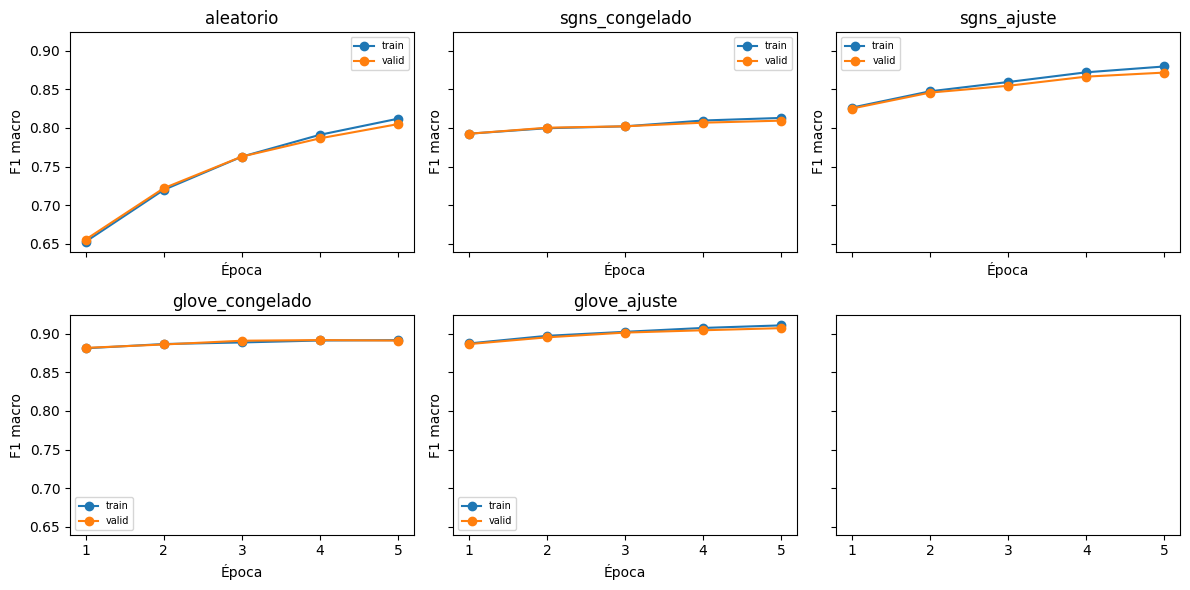

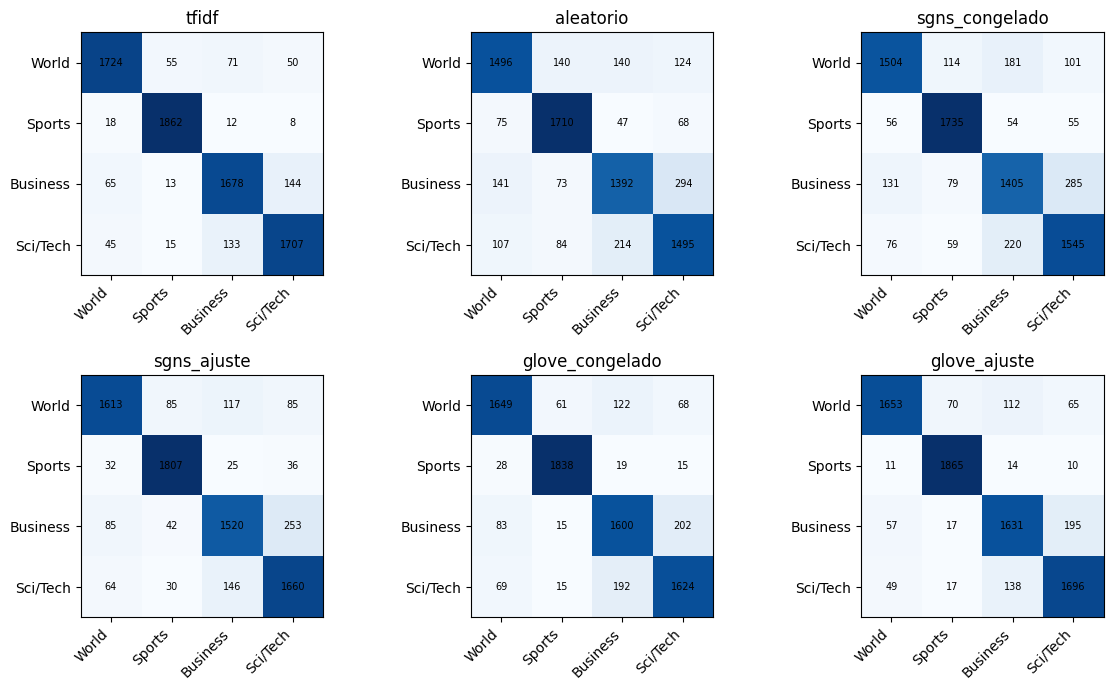

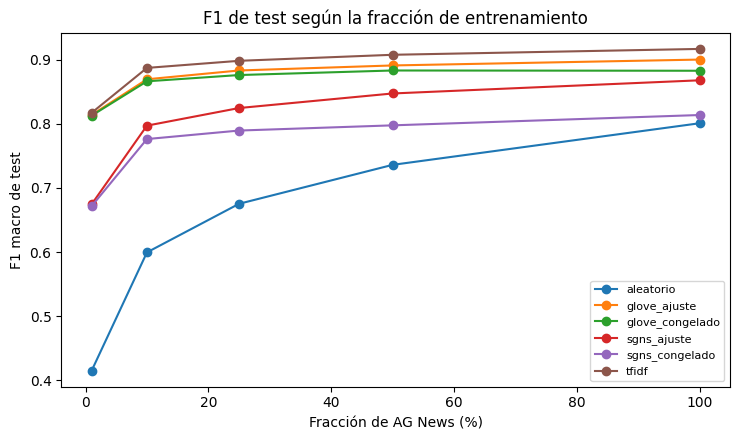

Reporte escrito en ../artifacts/reporte_lab07.pdf


,modelo,fraccion,accuracy,precision_macro,recall_macro,f1_macro,parametros_totales,parametros_entrenables,segundos,c
0,tfidf,1.0,0.9172,0.9171,0.9172,0.9171,183700,183700,60.8866,1.0
1,aleatorio,1.0,0.8017,0.8014,0.8017,0.8010,7849744,7849744,49.8433,NaN
2,sgns_congelado,1.0,0.8143,0.8144,0.8143,0.8139,7849744,13444,44.4976,NaN
3,sgns_ajuste,1.0,0.8684,0.8690,0.8684,0.8681,7849744,7849744,49.4195,NaN
4,glove_congelado,1.0,0.8830,0.8832,0.8830,0.8830,7849744,13444,43.4225,NaN
5,glove_ajuste,1.0,0.9007,0.9011,0.9007,0.9005,7849744,7849744,49.5364,NaN


,modelo,fraccion,f1_macro
7,aleatorio,0.01,0.4148
13,aleatorio,0.10,0.5994
19,aleatorio,0.25,0.6753
25,aleatorio,0.50,0.7361
1,aleatorio,1.00,0.8010
11,glove_ajuste,0.01,0.8141
17,glove_ajuste,0.10,0.8697
23,glove_ajuste,0.25,0.8834
29,glove_ajuste,0.50,0.8913
5,glove_ajuste,1.00,0.9005


,modelo,corpus,vocabulario,dimension,segundos,hardware,analogias_add,analogias_mul,analogias_semanticas,analogias_sintacticas,...,wordsim,wordsim_cobertura,simlex,simlex_cobertura,wordsim_compartido,simlex_compartido,similitud_diferencias,oov_agnews,f1_congelado,f1_ajuste
0,sgns,"WikiText-103, 20M tokens",78361,100,1584.9761,Linux-6.6.122+-x86_64-with-glibc2.39; disposit...,0.0021,0.0011,0.0016,0.0024,...,0.1658,0.9943,0.0393,0.994,0.1732,0.0390,0.0068,0.0511,0.8139,0.8681
1,gensim,"WikiText-103, 20M tokens",78361,100,806.3338,Linux-6.6.122+-x86_64-with-glibc2.39; disposit...,0.3189,0.2884,0.2785,0.3376,...,0.6067,0.9943,0.3014,0.994,0.6173,0.2966,0.1625,0.0511,NaN,NaN
2,glove,Wikipedia 2014 + Gigaword 5,400000,100,52.3627,Linux-6.6.122+-x86_64-with-glibc2.39; disposit...,0.6568,0.6380,0.6098,0.6786,...,0.5287,0.9972,0.2975,1.000,0.5546,0.3036,0.4180,0.0150,0.8830,0.9005


In [28]:
import textwrap
from collections import OrderedDict

from IPython.display import display
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

EPOCHS_CLF = 5
BATCH_CLF = 256
FRACCIONES = (0.01, 0.10, 0.25, 0.50, 1.0)
C_GRID = (0.1, 1.0, 10.0)
CLASES = ['World', 'Sports', 'Business', 'Sci/Tech']
test_ya_evaluado = set()

textos_ent, textos_val, y_ent, y_val = train_test_split(
    textos_ag, etiquetas_ag, test_size=0.1, stratify=etiquetas_ag, random_state=SEED,
)

def oov_multiple(textos, vocabularios):
    vocabularios = {nombre: set(palabras) for nombre, palabras in vocabularios.items()}
    total = 0
    fuera = {nombre: 0 for nombre in vocabularios}
    for texto in textos:
        for token in tokenize(texto):
            total += 1
            for nombre, vocabulario in vocabularios.items():
                fuera[nombre] += token not in vocabulario
    return {nombre: (fuera[nombre] / total if total else float('nan')) for nombre in vocabularios}

oov_ag = oov_multiple(textos_ag, {
    'sgns': espacio_sgns.palabras,
    'gensim': espacio_gensim.palabras,
    'glove': espacio_glove.palabras,
})
print('OOV en el entrenamiento de AG News:', {k: round(v, 4) for k, v in oov_ag.items()})

class Noticias(torch.utils.data.Dataset):
    def __init__(self, textos, etiquetas):
        self.textos = list(textos)
        self.etiquetas = list(etiquetas)

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, indice):
        ids = [token_to_id.get(token, token_to_id[UNK]) for token in tokenize(self.textos[indice])]
        return ids or [token_to_id[UNK]], int(self.etiquetas[indice])

def colacion(lote):
    piezas, offsets, etiquetas, cursor = [], [], [], 0
    for ids, etiqueta in lote:
        offsets.append(cursor)
        piezas.extend(ids)
        cursor += len(ids)
        etiquetas.append(etiqueta)
    return (
        torch.tensor(piezas, dtype=torch.long),
        torch.tensor(offsets, dtype=torch.long),
        torch.tensor(etiquetas, dtype=torch.long),
    )

def loader_de(textos, etiquetas, barajar):
    return DataLoader(Noticias(textos, etiquetas), batch_size=BATCH_CLF, shuffle=barajar, collate_fn=colacion)

class ClasificadorBolsa(nn.Module):
    def __init__(self, num_embeddings, dimension, num_clases, pesos=None, congelar=False):
        super().__init__()
        self.bolsa = nn.EmbeddingBag(num_embeddings, dimension, mode='mean', padding_idx=0)
        if pesos is not None:
            with torch.no_grad():
                self.bolsa.weight.copy_(torch.from_numpy(np.array(pesos, dtype=np.float32, copy=True)))
                self.bolsa.weight[0].zero_()
        self.bolsa.weight.requires_grad_(not congelar)
        self.mlp = nn.Sequential(
            nn.Linear(dimension, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_clases),
        )

    def forward(self, tokens, offsets):
        return self.mlp(self.bolsa(tokens, offsets))

def metricas_de(y_verdadero, y_predicho):
    return {
        'accuracy': accuracy_score(y_verdadero, y_predicho),
        'precision_macro': precision_score(y_verdadero, y_predicho, average='macro', zero_division=0),
        'recall_macro': recall_score(y_verdadero, y_predicho, average='macro', zero_division=0),
        'f1_macro': f1_score(y_verdadero, y_predicho, average='macro', zero_division=0),
    }

def parametros_de(modulo):
    total = sum(p.numel() for p in modulo.parameters())
    entrenables = sum(p.numel() for p in modulo.parameters() if p.requires_grad)
    return int(total), int(entrenables)

@torch.no_grad()
def predecir(modelo, loader):
    modelo.eval()
    verdaderas, predichas = [], []
    for tokens, offsets, etiquetas in loader:
        pred = modelo(tokens.to(DEVICE), offsets.to(DEVICE)).argmax(1).cpu()
        verdaderas.extend(etiquetas.tolist())
        predichas.extend(pred.tolist())
    return metricas_de(verdaderas, predichas), verdaderas, predichas

def evaluar_test(nombre, funcion):
    if nombre in test_ya_evaluado:
        raise RuntimeError(f'El test ya fue evaluado para {nombre}')
    test_ya_evaluado.add(nombre)
    return funcion()

def entrenar_bolsa(modelo, textos, etiquetas, epochs=EPOCHS_CLF):
    modelo.to(DEVICE)
    grupos = []
    ajustables = [p for p in modelo.bolsa.parameters() if p.requires_grad]
    if ajustables:
        grupos.append({'params': ajustables, 'lr': 1e-4})
    grupos.append({'params': list(modelo.mlp.parameters()), 'lr': 1e-3})
    optimizador = torch.optim.Adam(grupos)
    perdida_fn = nn.CrossEntropyLoss()
    loader_ent = loader_de(textos, etiquetas, True)
    loader_val = loader_de(textos_val, y_val, False)
    historial, mejor_f1, mejor_estado = [], -1.0, None
    inicio = perf_counter()
    for epoch in range(1, epochs + 1):
        modelo.train()
        perdida_acum = ejemplos = 0
        for tokens, offsets, objetivos in loader_ent:
            tokens, offsets, objetivos = tokens.to(DEVICE), offsets.to(DEVICE), objetivos.to(DEVICE)
            optimizador.zero_grad(set_to_none=True)
            perdida = perdida_fn(modelo(tokens, offsets), objetivos)
            perdida.backward()
            optimizador.step()
            perdida_acum += perdida.item() * len(objetivos)
            ejemplos += len(objetivos)
        train, _, _ = predecir(modelo, loader_ent)
        val, _, _ = predecir(modelo, loader_val)
        historial.append({
            'epoch': epoch,
            'loss': perdida_acum / max(ejemplos, 1),
            **{f'train_{clave}': valor for clave, valor in train.items()},
            **{f'val_{clave}': valor for clave, valor in val.items()},
        })
        if val['f1_macro'] > mejor_f1:
            mejor_f1 = val['f1_macro']
            mejor_estado = {clave: tensor.detach().cpu().clone() for clave, tensor in modelo.state_dict().items()}
    segundos = perf_counter() - inicio
    modelo.load_state_dict(mejor_estado)
    return pd.DataFrame(historial), segundos

def nuevo_clasificador(inicializacion, congelar):
    torch.manual_seed(SEED)
    if inicializacion == 'aleatorio':
        return ClasificadorBolsa(len(id_to_token), DIMENSION, len(CLASES))
    if inicializacion == 'sgns':
        return ClasificadorBolsa(len(id_to_token), DIMENSION, len(CLASES), pesos=pesos_sgns, congelar=congelar)
    if inicializacion == 'glove':
        return ClasificadorBolsa(len(id_to_token), pesos_glove.shape[1], len(CLASES), pesos=pesos_glove, congelar=congelar)
    raise ValueError(inicializacion)

def muestra_estratificada(textos, etiquetas, fraccion):
    if fraccion >= 1:
        return list(textos), list(etiquetas)
    textos_m, _, etiquetas_m, _ = train_test_split(
        list(textos), list(etiquetas), train_size=fraccion, stratify=etiquetas, random_state=SEED,
    )
    return textos_m, etiquetas_m

def entrenar_tfidf(textos, etiquetas, c_fijo=None):
    vectorizador = TfidfVectorizer(
        tokenizer=tokenize, preprocessor=lambda texto: texto, token_pattern=None,
        lowercase=False, min_df=2, max_features=50_000, dtype=np.float32,
    )
    inicio = perf_counter()
    x_ent = vectorizador.fit_transform(textos)
    x_val = vectorizador.transform(textos_val)
    mejor = None
    valores_c = (c_fijo,) if c_fijo is not None else C_GRID
    for c in valores_c:
        clasificador = LogisticRegression(C=c, max_iter=500, solver='lbfgs')
        clasificador.fit(x_ent, etiquetas)
        f1_val = f1_score(y_val, clasificador.predict(x_val), average='macro', zero_division=0)
        if mejor is None or f1_val > mejor['f1_val']:
            mejor = {'c': c, 'f1_val': f1_val, 'modelo': clasificador, 'vectorizador': vectorizador}
    segundos = perf_counter() - inicio
    return mejor, segundos

configuraciones = [
    ('tfidf', None, None),
    ('aleatorio', 'aleatorio', False),
    ('sgns_congelado', 'sgns', True),
    ('sgns_ajuste', 'sgns', False),
    ('glove_congelado', 'glove', True),
    ('glove_ajuste', 'glove', False),
]
resultados_clf = []
historiales = {}
matrices = OrderedDict()
loader_test = loader_de(textos_ag_test, etiquetas_ag_test, False)

mejor_tfidf, segundos_tfidf = entrenar_tfidf(textos_ent, y_ent)
c_elegida = mejor_tfidf['c']

def predecir_tfidf():
    x_test = mejor_tfidf['vectorizador'].transform(textos_ag_test)
    pred = mejor_tfidf['modelo'].predict(x_test)
    return metricas_de(etiquetas_ag_test, pred), etiquetas_ag_test, list(pred)

metricas_tfidf, _, pred_tfidf = evaluar_test('tfidf|1', predecir_tfidf)
coef = mejor_tfidf['modelo'].coef_
resultados_clf.append({
    'modelo': 'tfidf',
    'fraccion': 1.0,
    'accuracy': metricas_tfidf['accuracy'],
    'precision_macro': metricas_tfidf['precision_macro'],
    'recall_macro': metricas_tfidf['recall_macro'],
    'f1_macro': metricas_tfidf['f1_macro'],
    'parametros_totales': int(coef.size + mejor_tfidf['modelo'].intercept_.size),
    'parametros_entrenables': int(coef.size + mejor_tfidf['modelo'].intercept_.size),
    'segundos': segundos_tfidf,
    'c': c_elegida,
})
matrices['tfidf'] = confusion_matrix(etiquetas_ag_test, pred_tfidf, labels=[0, 1, 2, 3])

for nombre, inicializacion, congelar in configuraciones[1:]:
    clasificador = nuevo_clasificador(inicializacion, congelar)
    totales, entrenables = parametros_de(clasificador)
    historial, segundos = entrenar_bolsa(clasificador, textos_ent, y_ent)
    historiales[nombre] = historial

    def predecir_red(modelo=clasificador):
        return predecir(modelo, loader_test)

    metricas_test, y_test, pred_test = evaluar_test(f'{nombre}|1', predecir_red)
    resultados_clf.append({
        'modelo': nombre,
        'fraccion': 1.0,
        'accuracy': metricas_test['accuracy'],
        'precision_macro': metricas_test['precision_macro'],
        'recall_macro': metricas_test['recall_macro'],
        'f1_macro': metricas_test['f1_macro'],
        'parametros_totales': totales,
        'parametros_entrenables': entrenables,
        'segundos': segundos,
        'c': None,
    })
    matrices[nombre] = confusion_matrix(y_test, pred_test, labels=[0, 1, 2, 3])

clasificacion = pd.DataFrame(resultados_clf)
filas_fraccion = clasificacion[['modelo', 'fraccion', 'f1_macro']].copy()

for fraccion in FRACCIONES:
    if fraccion == 1:
        continue
    textos_m, y_m = muestra_estratificada(textos_ent, y_ent, fraccion)
    ajustado, segundos = entrenar_tfidf(textos_m, y_m, c_fijo=c_elegida)

    def predecir_fraccion_tfidf(modelo=ajustado):
        pred = modelo['modelo'].predict(modelo['vectorizador'].transform(textos_ag_test))
        return metricas_de(etiquetas_ag_test, pred), etiquetas_ag_test, list(pred)

    metricas_fraccion, _, _ = evaluar_test(f'tfidf|{fraccion}', predecir_fraccion_tfidf)
    filas_fraccion = pd.concat([filas_fraccion, pd.DataFrame([{
        'modelo': 'tfidf', 'fraccion': fraccion, 'f1_macro': metricas_fraccion['f1_macro'],
    }])], ignore_index=True)
    for nombre, inicializacion, congelar in configuraciones[1:]:
        clasificador = nuevo_clasificador(inicializacion, congelar)
        _, _ = entrenar_bolsa(clasificador, textos_m, y_m)

        def predecir_fraccion(modelo=clasificador):
            return predecir(modelo, loader_test)

        metricas_fraccion, _, _ = evaluar_test(f'{nombre}|{fraccion}', predecir_fraccion)
        filas_fraccion = pd.concat([filas_fraccion, pd.DataFrame([{
            'modelo': nombre, 'fraccion': fraccion, 'f1_macro': metricas_fraccion['f1_macro'],
        }])], ignore_index=True)

fracciones_df = filas_fraccion.sort_values(['modelo', 'fraccion'])

if historiales:
    figura_curvas, ejes_curvas = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
    for eje, (nombre, historial) in zip(ejes_curvas.ravel(), historiales.items()):
        eje.plot(historial['epoch'], historial['train_f1_macro'], marker='o', label='train')
        eje.plot(historial['epoch'], historial['val_f1_macro'], marker='o', label='valid')
        eje.set_title(nombre)
        eje.set_xlabel('Época')
        eje.set_ylabel('F1 macro')
        eje.legend(fontsize=7)
    figura_curvas.tight_layout()
    figura_curvas.savefig(ARTIFACTS / 'curvas_clasificacion.png', dpi=150, bbox_inches='tight')
    plt.show()

figura_matrices, ejes_matrices = plt.subplots(2, 3, figsize=(12, 7))
for eje, (nombre, matriz) in zip(ejes_matrices.ravel(), matrices.items()):
    eje.imshow(matriz, cmap='Blues')
    eje.set_title(nombre)
    eje.set_xticks(range(4), CLASES, rotation=45, ha='right')
    eje.set_yticks(range(4), CLASES)
    for i in range(4):
        for j in range(4):
            eje.text(j, i, int(matriz[i, j]), ha='center', va='center', fontsize=7)
figura_matrices.tight_layout()
figura_matrices.savefig(ARTIFACTS / 'matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

figura_fraccion, eje_fraccion = plt.subplots(figsize=(7.5, 4.5))
for nombre, grupo in fracciones_df.groupby('modelo'):
    grupo = grupo.sort_values('fraccion')
    eje_fraccion.plot(grupo['fraccion'] * 100, grupo['f1_macro'], marker='o', label=nombre)
eje_fraccion.set_xlabel('Fracción de AG News (%)')
eje_fraccion.set_ylabel('F1 macro de test')
eje_fraccion.set_title('F1 de test según la fracción de entrenamiento')
eje_fraccion.legend(fontsize=8)
figura_fraccion.tight_layout()
figura_fraccion.savefig(ARTIFACTS / 'f1_vs_fraccion.png', dpi=150, bbox_inches='tight')
plt.show()

mapa_f1 = {
    'sgns': ('sgns_congelado', 'sgns_ajuste'),
    'gensim': (None, None),
    'glove': ('glove_congelado', 'glove_ajuste'),
}
comparacion['oov_agnews'] = comparacion['modelo'].map(oov_ag)
comparacion['f1_congelado'] = comparacion['modelo'].map(lambda nombre: clasificacion.loc[clasificacion['modelo'] == mapa_f1[nombre][0], 'f1_macro'].iloc[0] if mapa_f1[nombre][0] else float('nan'))
comparacion['f1_ajuste'] = comparacion['modelo'].map(lambda nombre: clasificacion.loc[clasificacion['modelo'] == mapa_f1[nombre][1], 'f1_macro'].iloc[0] if mapa_f1[nombre][1] else float('nan'))
comparacion.to_csv(ARTIFACTS / 'comparacion_global.csv', index=False)
clasificacion.to_csv(ARTIFACTS / 'clasificacion_agnews.csv', index=False)
fracciones_df.to_csv(ARTIFACTS / 'f1_fracciones.csv', index=False)

def lineas(parrafo, ancho=108):
    return textwrap.wrap(parrafo, width=ancho) or ['']

def nueva_pagina(titulo):
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.patch.set_facecolor('white')
    fig.text(0.07, 0.96, titulo, fontsize=13, fontweight='bold', va='top')
    return fig, 0.92

def escribir(fig, y, parrafos):
    for parrafo in parrafos:
        for linea in lineas(parrafo):
            y -= 0.018
            fig.text(0.07, y, linea, fontsize=8.5, va='top')
        y -= 0.01
    return y

def pegar_tabla(fig, y, tabla):
    visible = tabla.copy()
    for columna in visible.columns:
        if pd.api.types.is_numeric_dtype(visible[columna]):
            visible[columna] = visible[columna].map(lambda valor: '' if pd.isna(valor) else f'{valor:.3f}')
    alto = min(0.45, 0.035 * (len(visible) + 1))
    ax = fig.add_axes([0.07, max(0.05, y - alto - 0.02), 0.86, alto])
    ax.axis('off')
    tabla_fig = ax.table(cellText=visible.values, colLabels=list(visible.columns), loc='upper center', cellLoc='center')
    tabla_fig.auto_set_font_size(False)
    tabla_fig.set_fontsize(6)
    tabla_fig.scale(1, 1.15)
    return y - alto - 0.04

fila = comparacion.set_index('modelo')
def cifra(modelo, columna):
    valor = fila.loc[modelo, columna]
    return 'n/d' if pd.isna(valor) else f'{valor:.3f}'

f1_texto = []
for nombre, grupo in fracciones_df.groupby('modelo'):
    grupo = grupo.sort_values('fraccion')
    pares = ', '.join(f'{int(fraccion * 100)} %: {f1:.3f}' for fraccion, f1 in zip(grupo['fraccion'], grupo['f1_macro']))
    f1_texto.append(f'{nombre}: {pares}.')

discusion = [
    'La misma tokenización se aplica a WikiText y a AG News: minúsculas, puntuación aislada fuera, contracciones y guiones internos conservados, números en texto. SGNS exporta la tabla de entrada. GloVe no se ajusta antes de la evaluación semántica y mantiene su vocabulario; el OOV de AG News queda en '
    + ', '.join(f'{nombre} {valor:.1%}' for nombre, valor in oov_ag.items()) + '.',
    'EmbeddingBag en modo mean promedia los vectores de cada noticia. offsets indica el inicio de cada documento en el tensor plano, así que el lote no necesita relleno. El índice de relleno no entra en el promedio ni recibe gradiente.',
    'CBOW predice la palabra central desde el contexto. Skip-gram predice el contexto desde la palabra central y actualiza más veces las palabras raras. El SGNS propio y gensim son skip-gram. Word2Vec aprende pares locales con muestreo negativo. GloVe factoriza coocurrencias globales y aquí entra preentrenado en 100 dimensiones.',
    'En el vocabulario compartido, la accuracy 3CosAdd es '
    + ', '.join(f'{nombre} {cifra(nombre, "analogias_add")}' for nombre in ('sgns', 'gensim', 'glove'))
    + '. Con 3CosMul: '
    + ', '.join(f'{nombre} {cifra(nombre, "analogias_mul")}' for nombre in ('sgns', 'gensim', 'glove'))
    + '. El coseno medio entre vectores diferencia es '
    + ', '.join(f'{nombre} {cifra(nombre, "similitud_diferencias")}' for nombre in ('sgns', 'gensim', 'glove'))
    + '. Un valor más alto indica que la relación ocupa una dirección más estable.',
    'WordSim-353 y SimLex-999, medidos con el vocabulario de cada modelo, dan Spearman '
    + ', '.join(f'{nombre} WordSim {cifra(nombre, "wordsim")} y SimLex {cifra(nombre, "simlex")}' for nombre in ('sgns', 'gensim', 'glove'))
    + '. En clasificación, el F1 de test con ajuste es '
    + f'SGNS {cifra("sgns", "f1_ajuste")} y GloVe {cifra("glove", "f1_ajuste")}. '
    + f'El F1 congelado es SGNS {cifra("sgns", "f1_congelado")} y GloVe {cifra("glove", "f1_congelado")}.',
    'El test se consulta una sola vez por corrida, después de elegir C y la época con validación. Las fracciones no cambian esos hiperparámetros. '
    + ' '.join(f1_texto),
    f'Reproducir: pip install -r requirements.txt y ejecutar el notebook de principio a fin, con la semilla {SEED}. '
    f'El corpus son los primeros {TOKEN_LIMIT:,} tokens del entrenamiento de Salesforce/wikitext wikitext-103-raw-v1. '
    f'Repositorio: {REPO_URL}. Hardware: {HARDWARE}.',
]

if 'barrido_df' not in globals():
    import pandas as pd
    _hist = globals().get('history')
    _loss = float('nan')
    if isinstance(_hist, dict) and _hist.get('loss'):
        _loss = float(_hist['loss'][-1])
    barrido_df = pd.DataFrame([{
        'id': 'base_100d',
        'dimension': int(globals().get('DIMENSION', 100)),
        'fraccion': 1.0,
        'tokens': int(globals().get('TOKEN_LIMIT', 0) or 0),
        'vocabulario': len(globals().get('token_to_id', {}) or {}),
        'loss_final': _loss,
        'wordsim': float('nan'),
        'analogias_add': float('nan'),
        'analogias_mul': float('nan'),
        'analogias_semanticas': float('nan'),
        'analogias_sintacticas': float('nan'),
        'segundos': float('nan'),
        'gpu_mib_pico': float('nan'),
    }])
if 'mejor_config' not in globals():
    mejor_config = {'id': 'base_100d', 'wordsim': float('nan'), 'analogias_add': float('nan')}

tabla_iteraciones = barrido_df[[
    'id', 'dimension', 'fraccion', 'tokens', 'vocabulario', 'loss_final',
    'wordsim', 'analogias_add', 'analogias_mul', 'analogias_semanticas',
    'analogias_sintacticas', 'segundos', 'gpu_mib_pico',
]].copy()
tabla_iteraciones.to_csv(ARTIFACTS / 'tabla_iteraciones.csv', index=False)

tabla_global = comparacion[['modelo', 'vocabulario', 'dimension', 'analogias_add', 'analogias_mul', 'wordsim', 'simlex', 'similitud_diferencias', 'oov_agnews', 'f1_congelado', 'f1_ajuste']].copy()
tabla_cat = categorias_df[categorias_df['metodo'] == '3cosadd'].pivot(index='categoria', columns='modelo', values='accuracy').reset_index()
tabla_clf = clasificacion[['modelo', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'parametros_totales', 'parametros_entrenables', 'segundos']].copy()

with PdfPages(ARTIFACTS / 'reporte_lab07.pdf') as pdf:
    fig, y = nueva_pagina('Laboratorio 7. Pipeline e investigación')
    y = escribir(fig, y, discusion[:3] + [
        f'Barrido SGNS: se probaron {len(barrido_df)} configuraciones; la elegida es {mejor_config["id"]} '
        f'(WordSim={mejor_config["wordsim"]:.3f}, 3CosAdd={mejor_config["analogias_add"]:.3f}).',
    ])
    y = pegar_tabla(fig, y, tabla_iteraciones)
    pdf.savefig(fig)
    plt.close(fig)

    fig, y = nueva_pagina('Comparación de embeddings')
    y = escribir(fig, y, [discusion[3], discusion[4]])
    pegar_tabla(fig, y, tabla_global)
    pdf.savefig(fig)
    plt.close(fig)

    fig, y = nueva_pagina('Analogías por categoría (3CosAdd)')
    y = escribir(fig, y, [
        'Las categorías salen de questions-words.txt. La accuracy usa solo las preguntas cuyas cuatro palabras están en las 30 000 más frecuentes presentes en SGNS, gensim y GloVe. El candidato se busca dentro de ese mismo vocabulario.',
    ])
    pegar_tabla(fig, y, tabla_cat)
    pdf.savefig(fig)
    plt.close(fig)

    fig, y = nueva_pagina('Clasificación en AG News')
    y = escribir(fig, y, [
        f'La regresión logística usa C = {c_elegida:g}, elegido en validación. El MLP tiene una capa oculta de 128 unidades y se conserva la época con mejor F1 macro de validación. El gráfico de F1 contra la fracción de datos está en artifacts/f1_vs_fraccion.png.',
    ])
    y = pegar_tabla(fig, y, tabla_clf)
    ax = fig.add_axes([0.12, 0.08, 0.75, 0.28])
    for nombre, grupo in fracciones_df.groupby('modelo'):
        grupo = grupo.sort_values('fraccion')
        ax.plot(grupo['fraccion'] * 100, grupo['f1_macro'], marker='o', label=nombre)
    ax.set_xlabel('Fracción de AG News (%)')
    ax.set_ylabel('F1 macro de test')
    ax.legend(fontsize=6, ncol=3)
    pdf.savefig(fig)
    plt.close(fig)

    fig, y = nueva_pagina('Discusión y reproducción')
    escribir(fig, y, discusion[5:])
    pdf.savefig(fig)
    plt.close(fig)

print(f'Reporte escrito en {ARTIFACTS / "reporte_lab07.pdf"}')
display(clasificacion.round(4))
display(fracciones_df.round(4))
comparacion.round(4)
